In [302]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
# # import  settings

sys.path.append('..')
import plot_settings
importlib.reload(sim_PyBaMM)
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver2
importlib.reload(exp_pybamm_ver2)

<module 'exp_pybamm_ver2' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/../exp_pybamm_ver2.py'>

In [303]:
from neuralop.models import FNO

In [304]:
def get_values(param,model=None):
    sol, model, t_eval = exp_pybamm_ver2.generate_data()
    vals = sol.observe(model.variables[param])
    I = sol.observe(model.variables['Current variable [A]'])
    t_ = np.linspace(0, sol['Time [s]'].entries[-1], 1000)

    return t_, t_eval, I(t_), vals(t_)


In [305]:
def gen_data_NO(batches):
    I = np.zeros((batches,1,1000))
    cn = np.zeros((batches,22,1000))
    for i in trange(batches):
        t,_, I[i,0,:], cn[i,...] = exp_pybamm_ver2.get_values('X-averaged negative particle concentration [mol.m-3]',model = 'SPM')
        #rn[i,:,:] = Rn.mean(axis=1)
    return I, cn, t

In [306]:
I ,cn, t = gen_data_NO(150)

100%|██████████| 150/150 [01:36<00:00,  1.56it/s]


In [307]:
def grid_gen(xlim, ylim, size):  
    x_size =  size[0]; y_size = size[1]

    x = np.linspace(xlim[0], xlim[1], int(x_size))
    y = np.linspace(ylim[0], ylim[1], int(y_size))
    X, Y = np.meshgrid(x, y)
    return X, Y

In [308]:
T, R = grid_gen([0,int(t[-1])],[0,10], size=[1000,22])

In [309]:
cn /= cn[:,:,0][:,:,None]  # Normalize by the initial value at each spatial point

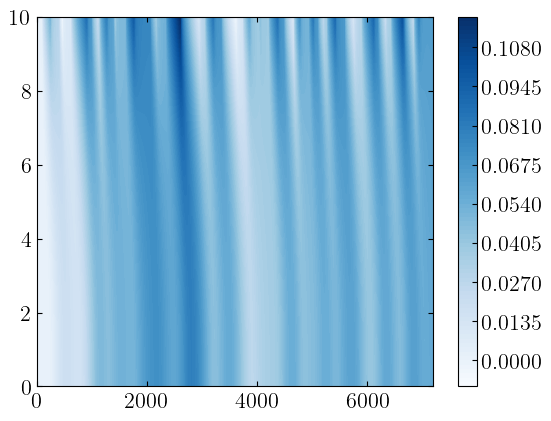

In [310]:
plt.contourf(T,R,cn[1,...]- cn[0,...],levels = 100, cmap='Blues')
plt.colorbar()

In [311]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']

In [312]:


# np.savez('data_NO/I.npz',np.vstack((I,I_gen)))
# np.savez('data_NO/V.npz',np.vstack((V,V_gen)))

In [331]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']



test_size = 0.1
I_test = I[0:int(test_size * len(I)),:,:]; cn_test = cn[0:int(test_size * len(I)),:,:]
I_train = I[int(test_size * len(I)):,:,:]; cn_train = cn[int(test_size * len(I)):,:,:]

In [ ]:
from neuralop.models import FNO 
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         
    hidden_channels=64, 
    in_channels=1,      
    out_channels=22,     
)

from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I, dtype=torch.float32), 
                        torch.tensor(cn, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))

In [ ]:



optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

torch.Size([32, 22, 1000])


In [ ]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  
            y_pred = model(u_batch)
            IC_loss = loss_fn(y_pred[:,:,0], y_batch[:,:,0])  # Initial condition loss
            loss = loss_fn(y_pred, y_batch) + 0.1*IC_loss 
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [381]:
model, history = training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 0.5928 ETA: 5:13
Epoch 2 average loss: 0.4618 ETA: 4:39
Epoch 3 average loss: 0.2297 ETA: 4:31
Epoch 4 average loss: 0.0973 ETA: 4:26
Epoch 5 average loss: 0.0424 ETA: 4:21
Epoch 6 average loss: 0.0399 ETA: 4:19
Epoch 7 average loss: 0.0313 ETA: 4:07
Epoch 8 average loss: 0.0185 ETA: 4:01
Epoch 9 average loss: 0.0079 ETA: 3:57
Epoch 10 average loss: 0.0067 ETA: 3:50
Epoch 11 average loss: 0.0053 ETA: 3:45
Epoch 12 average loss: 0.0044 ETA: 3:40
Epoch 13 average loss: 0.0036 ETA: 3:32
Epoch 14 average loss: 0.0031 ETA: 3:34
Epoch 15 average loss: 0.0026 ETA: 3:22
Epoch 16 average loss: 0.0023 ETA: 3:16
Epoch 17 average loss: 0.0021 ETA: 3:11
Epoch 18 average loss: 0.0018 ETA: 3:05
Epoch 19 average loss: 0.0017 ETA: 2:59
Epoch 20 average loss: 0.0015 ETA: 2:53
Epoch 21 average loss: 0.0014 ETA: 2:50
Epoch 22 average loss: 0.0014 ETA: 2:49
Epoch 23 average loss: 0.0012 ETA: 2:41
Epoch 24 average loss: 0.0013 ETA: 2:30
Epoch 25 average loss: 0.0012 ETA: 2:23
Epoch 26 

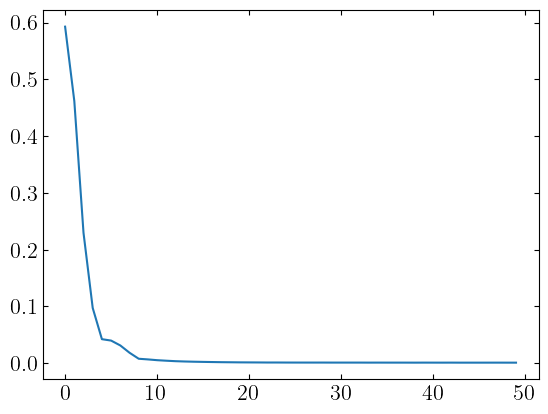

In [382]:
plt.plot(history['loss'])

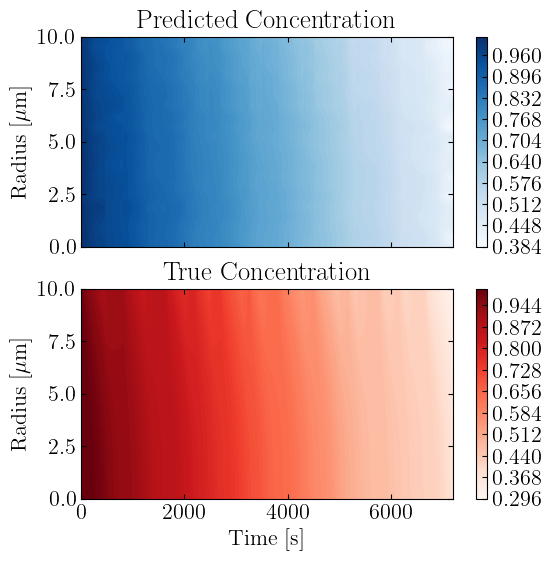

In [410]:
test = 5
i = I_test[test,0,:].reshape(1, 1, 1000) 
c_t = cn_test[test,:,:].reshape(1, 22, 1000)

#print(i.shape, v.shape)
c_pred = model(torch.tensor(i, dtype=torch.float32)).detach().numpy()
f, ax = plt.subplots(2,1,figsize=(6,6), sharex=True)
#f.subplots_adjust(hspace=0.05)¨


ax[0].contourf(T,R,c_pred[0,...],levels = 100, cmap='Blues', label='Predicted')
ax[1].contourf(T,R,c_t[0,...],levels = 100, cmap='Reds', label ='True')
ax[1].set_xlabel('Time [s]')
ax[0].set_ylabel('Radius [$\mu$m]')
ax[1].set_ylabel('Radius [$\mu$m]')
ax[0].set_title('Predicted Concentration')
ax[1].set_title('True Concentration')

#ax[1].contourf(T,R,c_t[0,...] - c_pred[0,...],levels = 100, cmap='coolwarm')
cb = plt.colorbar(ax[1].collections[0], ax=ax[1], orientation='vertical')
cb = plt.colorbar(ax[0].collections[0], ax=ax[0], orientation='vertical')
#plt.savefig('figs_NO/NO_concentration.pdf', bbox_inches='tight')

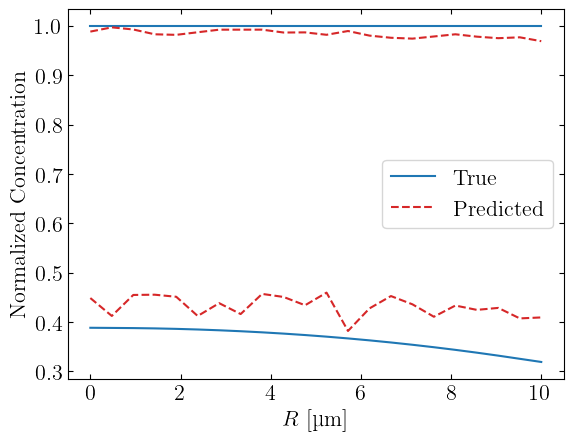

In [391]:

plt.plot(np.linspace(0,10,22), c_t[0,:,0], label='True', color='tab:blue')
plt.plot(np.linspace(0,10,22), c_pred[0,:,0].detach().numpy(), label='Predicted', color='tab:red', linestyle='--')
plt.plot(np.linspace(0,10,22), c_t[0,:,-1], color='tab:blue')
plt.plot(np.linspace(0,10,22), c_pred[0,:,-1].detach().numpy(), color='tab:red', linestyle='--')

plt.xlabel('$R$ [µm]')
plt.ylabel('Normalized Concentration')
plt.legend()

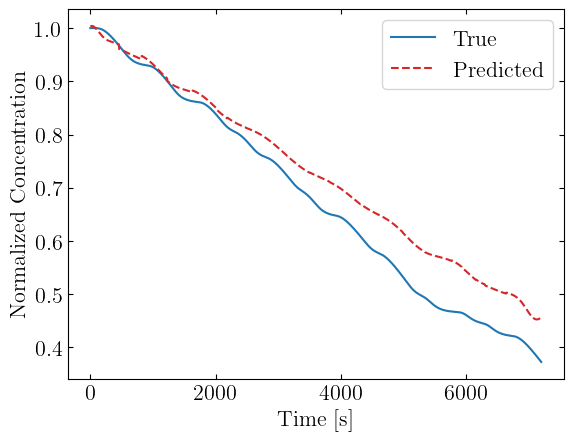

In [ ]:
plt.plot(t, np.mean(c_t[:,0,:],axis =0), label='True', color='tab:blue')
plt.plot(t, np.mean(c_pred[:,0,:],axis = 0), label='Predicted', color='tab:red', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Normalized Concentration')
plt.legend()
#plt.savefig('figs_NO/NO_R_avg_concentration_time.pdf', bbox_inches='tight')
